In [580]:
import pandas as pd
import numpy as np
import matplotlib as plt


df = pd.read_csv('../Data/Clean/googleplaystore_clean.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Subway Surfers,GAME,4.5,27711703,76M,1000000000,Free,0.0,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up
1,Hangouts,COMMUNICATION,4.0,3419464,Varies with device,1000000000,Free,0.0,Everyone,Communication,"July 21, 2018",Varies with device,Varies with device
2,Google,TOOLS,4.4,8021623,Varies with device,1000000000,Free,0.0,Everyone,Tools,"August 3, 2018",Varies with device,Varies with device
3,WhatsApp Messenger,COMMUNICATION,4.4,69109672,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
4,Google News,NEWS_AND_MAGAZINES,3.9,877643,13M,1000000000,Free,0.0,Teen,News & Magazines,"August 1, 2018",5.2.0,4.4 and up


In [581]:
df.shape

(8196, 13)

In [582]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8196 entries, 0 to 8195
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   str    
 1   Category        8196 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            8196 non-null   str    
 5   Installs        8196 non-null   int64  
 6   Type            8196 non-null   str    
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   str    
 9   Genres          8196 non-null   str    
 10  Last Updated    8196 non-null   str    
 11  Current Ver     8196 non-null   str    
 12  Android Ver     8196 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 832.5 KB


In [583]:
df.describe()

,Rating,Reviews,Installs,Price
count,8196.000000,8.196000e+03,8.196000e+03,8196.000000
mean,4.173280,2.554289e+05,9.189442e+06,1.035447
std,0.536266,1.985102e+06,5.826274e+07,16.857244
min,1.000000,1.000000e+00,1.000000e+00,0.000000
25%,4.000000,1.270000e+02,1.000000e+04,0.000000
50%,4.300000,3.017000e+03,1.000000e+05,0.000000
75%,4.500000,4.397675e+04,1.000000e+06,0.000000
max,5.000000,7.812821e+07,1.000000e+09,400.000000


In [584]:
df[df['Price'] == 400]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
5622,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3M,10000,Paid,400.0,Everyone,Lifestyle,"May 3, 2018",1.0.1,4.1 and up


In [585]:
df.describe(include=['object','string'])

,App,Category,Size,Type,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,8196,8196,8196,8196,8196,8196,8196,8196,8196
unique,8196,33,414,2,6,114,1300,2627,31
top,Subway Surfers,FAMILY,Varies with device,Free,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,1,1635,1170,7594,6618,719,245,1015,1816


In [586]:
df['Category'].value_counts().head(10)

Category
FAMILY             1635
GAME                896
TOOLS               720
FINANCE             302
PRODUCTIVITY        301
LIFESTYLE           301
PERSONALIZATION     298
MEDICAL             290
PHOTOGRAPHY         263
BUSINESS            263
Name: count, dtype: int64

In [587]:
df['Type'].value_counts()

Type
Free    7594
Paid     602
Name: count, dtype: int64

In [588]:
df['Content Rating'].value_counts()

Content Rating
Everyone           6618
Teen                912
Mature 17+          357
Everyone 10+        305
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

In [589]:
category_avg_installs = (
  df.groupby('Category')['Installs']
  .mean()
  .sort_values(ascending=False)
)

print(category_avg_installs.head(10))

Category
COMMUNICATION         4.311813e+07
SOCIAL                2.703370e+07
VIDEO_PLAYERS         2.649863e+07
ENTERTAINMENT         2.077537e+07
PRODUCTIVITY          1.924608e+07
PHOTOGRAPHY           1.771157e+07
TRAVEL_AND_LOCAL      1.548053e+07
GAME                  1.402094e+07
NEWS_AND_MAGAZINES    1.161329e+07
TOOLS                 1.125101e+07
Name: Installs, dtype: float64


In [590]:
#df['Category'].value_counts()['GAME']
#df['Category'].value_counts()['COMMUNICATION']

In [591]:
df.groupby('Type')['Installs'].sum()

Type
Free    75259313856
Paid       57350382
Name: Installs, dtype: int64

In [592]:
df[['Installs', 'Rating']].corr(numeric_only=True)

,Installs,Rating
Installs,1.000000,0.040244
Rating,0.040244,1.000000


In [593]:
df[['Installs', 'Price']].corr(numeric_only=True)

,Installs,Price
Installs,1.000000,-0.009653
Price,-0.009653,1.000000


In [594]:
df.sort_values('Installs', ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Subway Surfers,GAME,4.5,27711703,76M,1000000000,Free,0.0,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up
1,Hangouts,COMMUNICATION,4.0,3419464,Varies with device,1000000000,Free,0.0,Everyone,Communication,"July 21, 2018",Varies with device,Varies with device
2,Google,TOOLS,4.4,8021623,Varies with device,1000000000,Free,0.0,Everyone,Tools,"August 3, 2018",Varies with device,Varies with device
3,WhatsApp Messenger,COMMUNICATION,4.4,69109672,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
4,Google News,NEWS_AND_MAGAZINES,3.9,877643,13M,1000000000,Free,0.0,Teen,News & Magazines,"August 1, 2018",5.2.0,4.4 and up
5,Google Street View,TRAVEL_AND_LOCAL,4.2,2129689,Varies with device,1000000000,Free,0.0,Everyone,Travel & Local,"August 6, 2018",Varies with device,Varies with device
6,Instagram,SOCIAL,4.5,66509917,Varies with device,1000000000,Free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
7,Google+,SOCIAL,4.2,4828372,Varies with device,1000000000,Free,0.0,Teen,Social,"July 26, 2018",Varies with device,Varies with device
8,Google Drive,PRODUCTIVITY,4.4,2731211,Varies with device,1000000000,Free,0.0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
9,Google Photos,PHOTOGRAPHY,4.5,10858538,Varies with device,1000000000,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device


In [595]:
df[df['Category'] == 'GAME'].sort_values('Installs', ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Subway Surfers,GAME,4.5,27711703,76M,1000000000,Free,0.0,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up
30,Temple Run 2,GAME,4.3,8119151,62M,500000000,Free,0.0,Everyone,Action,"July 5, 2018",1.49.1,4.0 and up
32,My Talking Tom,GAME,4.5,14892469,Varies with device,500000000,Free,0.0,Everyone,Casual,"July 19, 2018",4.8.0.132,4.1 and up
33,Pou,GAME,4.3,10486018,24M,500000000,Free,0.0,Everyone,Casual,"May 25, 2018",1.4.77,4.0 and up
55,Sniper 3D Gun Shooter: Free Shooting Games - FPS,GAME,4.6,7657490,Varies with device,100000000,Free,0.0,Mature 17+,Action,"August 2, 2018",Varies with device,Varies with device
56,Dr. Driving,GAME,4.5,4972230,9.9M,100000000,Free,0.0,Everyone,Racing,"March 2, 2018",1.52,4.0.3 and up
57,Vector,GAME,4.4,3058687,89M,100000000,Free,0.0,Everyone 10+,Arcade,"July 18, 2016",1.2.0,4.0 and up
58,Crossy Road,GAME,4.5,4229977,60M,100000000,Free,0.0,Everyone,Action,"August 1, 2018",3.1.0,5.0 and up
74,Mobile Legends: Bang Bang,GAME,4.4,8219586,99M,100000000,Free,0.0,Teen,Action,"July 24, 2018",1.2.97.3042,4.0.3 and up
79,Angry Birds Classic,GAME,4.4,5566908,97M,100000000,Free,0.0,Everyone,Arcade,"May 24, 2018",7.9.3,4.1 and up


In [596]:
df[df['Category'] == 'COMMUNICATION'].sort_values('Installs', ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1,Hangouts,COMMUNICATION,4.0,3419464,Varies with device,1000000000,Free,0.0,Everyone,Communication,"July 21, 2018",Varies with device,Varies with device
3,WhatsApp Messenger,COMMUNICATION,4.4,69109672,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
10,Gmail,COMMUNICATION,4.3,4604483,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 2, 2018",Varies with device,Varies with device
11,Google Chrome: Fast & Secure,COMMUNICATION,4.3,9643041,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
12,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
14,Skype - free IM & video calls,COMMUNICATION,4.1,10484169,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
27,Viber Messenger,COMMUNICATION,4.3,11334799,Varies with device,500000000,Free,0.0,Everyone,Communication,"July 18, 2018",Varies with device,Varies with device
37,Google Duo - High Quality Video Calls,COMMUNICATION,4.6,2083237,Varies with device,500000000,Free,0.0,Everyone,Communication,"July 31, 2018",37.1.206017801.DR37_RC14,4.4 and up
39,imo free video calls and chat,COMMUNICATION,4.3,4785892,11M,500000000,Free,0.0,Everyone,Communication,"June 8, 2018",9.8.000000010501,4.0 and up
40,UC Browser - Fast Download Private & Secure,COMMUNICATION,4.5,17712922,40M,500000000,Free,0.0,Teen,Communication,"August 2, 2018",12.8.5.1121,4.0 and up


In [597]:
df.groupby('Category')['Installs'].median().sort_values(ascending=False).head(10)

Category
EDUCATION         1000000.0
SHOPPING          1000000.0
COMMUNICATION     1000000.0
FOOD_AND_DRINK    1000000.0
ENTERTAINMENT     1000000.0
GAME              1000000.0
WEATHER           1000000.0
VIDEO_PLAYERS     1000000.0
PHOTOGRAPHY       1000000.0
SPORTS             500000.0
Name: Installs, dtype: float64

In [598]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.435556
EDUCATION              4.355752
ART_AND_DESIGN         4.351667
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
SOCIAL                 4.247291
GAME                   4.243527
WEATHER                4.243056
Name: Rating, dtype: float64

In [599]:
df.groupby('Category')['App'].count().sort_values().head(10)

Category
BEAUTY                42
EVENTS                45
PARENTING             50
COMICS                54
ART_AND_DESIGN        60
HOUSE_AND_HOME        61
LIBRARIES_AND_DEMO    64
WEATHER               72
AUTO_AND_VEHICLES     73
FOOD_AND_DRINK        94
Name: App, dtype: int64

In [600]:
category_count = df['Category'].value_counts()

In [601]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

Category
GAME                  12562762717
COMMUNICATION         11038241530
TOOLS                  8100724500
FAMILY                 5898979590
PRODUCTIVITY           5793070180
SOCIAL                 5487841475
PHOTOGRAPHY            4658143130
VIDEO_PLAYERS          3921797200
TRAVEL_AND_LOCAL       2894859300
NEWS_AND_MAGAZINES     2369110650
Name: Installs, dtype: int64

In [602]:
df.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10)

Category
COMMUNICATION         4.311813e+07
SOCIAL                2.703370e+07
VIDEO_PLAYERS         2.649863e+07
ENTERTAINMENT         2.077537e+07
PRODUCTIVITY          1.924608e+07
PHOTOGRAPHY           1.771157e+07
TRAVEL_AND_LOCAL      1.548053e+07
GAME                  1.402094e+07
NEWS_AND_MAGAZINES    1.161329e+07
TOOLS                 1.125101e+07
Name: Installs, dtype: float64

In [603]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.435556
EDUCATION              4.355752
ART_AND_DESIGN         4.351667
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
SOCIAL                 4.247291
GAME                   4.243527
WEATHER                4.243056
Name: Rating, dtype: float64

In [604]:
df.groupby('Type')['Installs'].sum()

Type
Free    75259313856
Paid       57350382
Name: Installs, dtype: int64

In [605]:
corr = df[['Installs', 'Rating', 'Price']].corr()

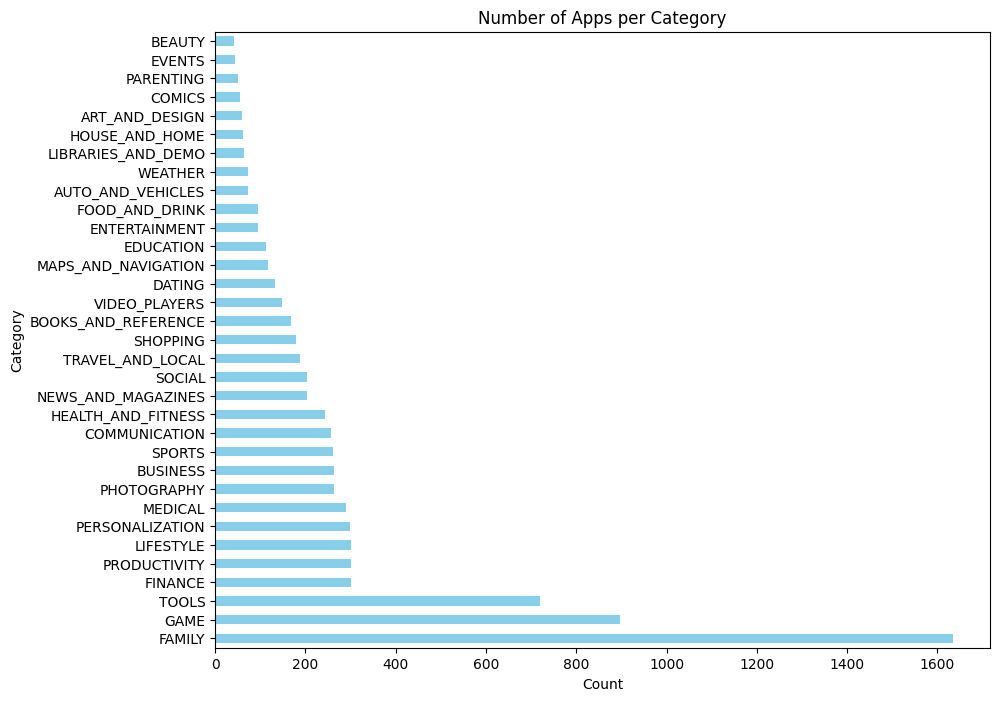

In [614]:
import matplotlib.pyplot as plt

category_count = df['Category'].value_counts()

category_count.plot(kind='barh', figsize=(10, 8), color='skyblue')

plt.title('Number of Apps per Category')
plt.xlabel('Count')
plt.ylabel('Category')

plt.show()